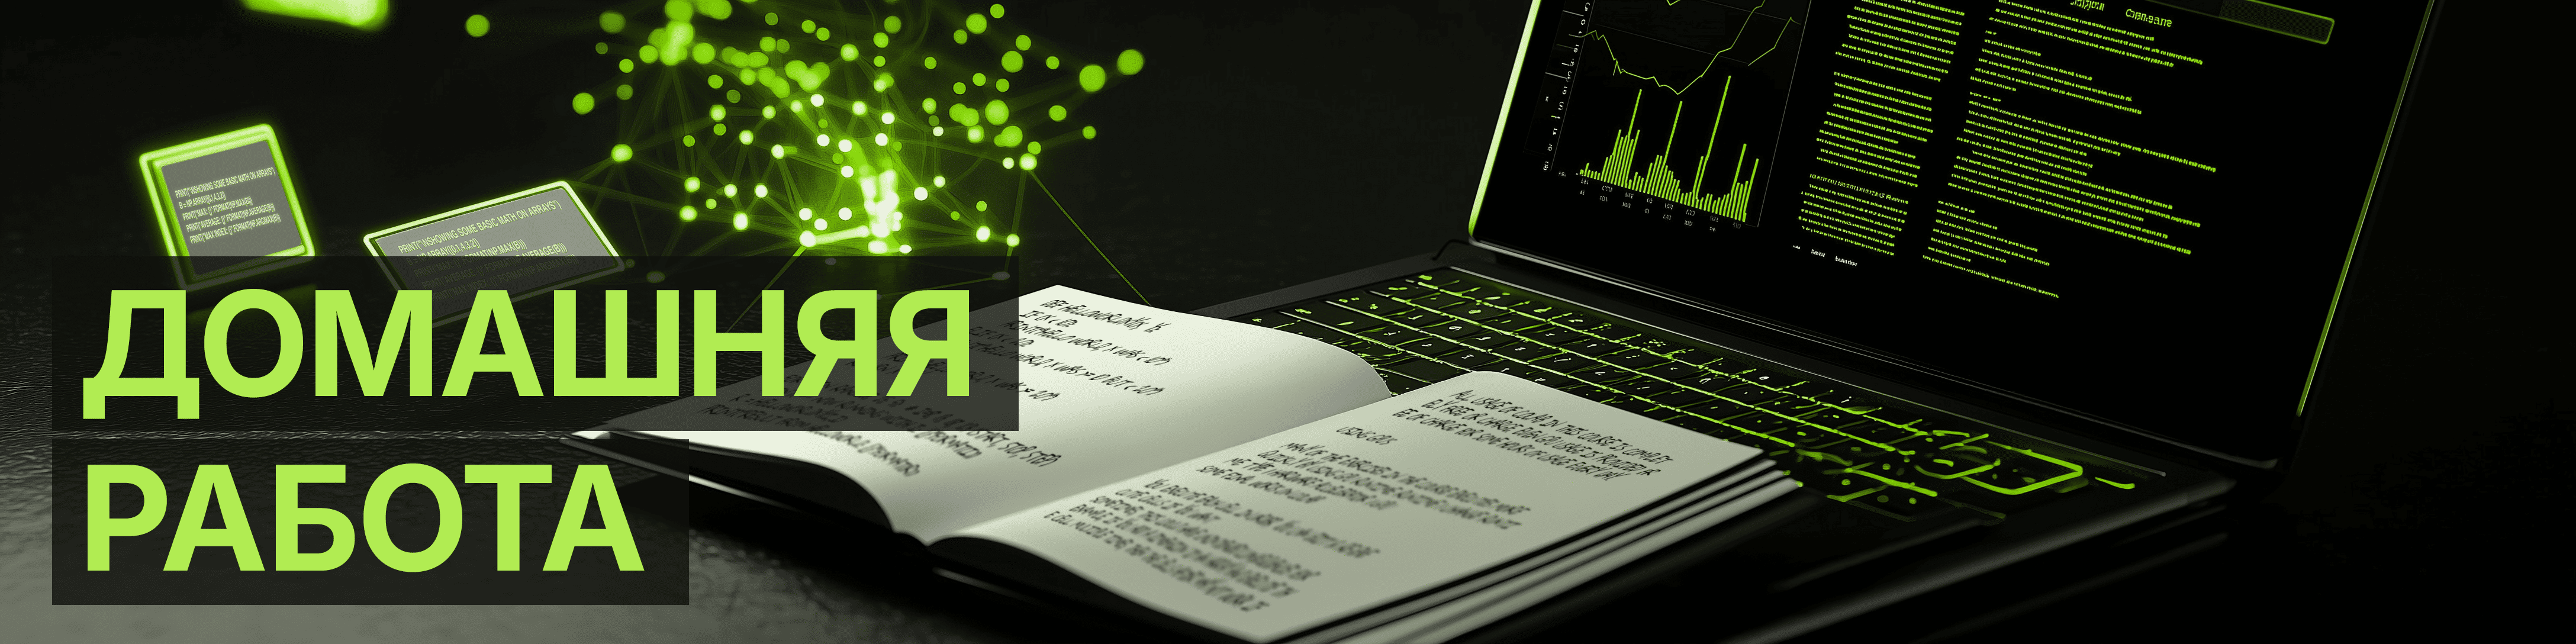

**Навигация по уроку**
1. [Автокодировщик GAN. Генеративно-состязательные сети](https://colab.research.google.com/drive/15hs_BV9OGUuaTmVetqYaAUf8zpDgxz3_)
2. [Сверточные GAN. Генерация фейковых лиц](https://colab.research.google.com/drive/1mCDkjVfw4-ZWysmat7LH-xAmssZj6ANU)
3. [CyrcleGAN. Создаем картины в стиле Моне](https://colab.research.google.com/drive/1SKpzFYFsiU53E1BpRS4waNzQ_mVk-XMz)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Ваша задача, используя датасет MNIST (из набора датасетов Tensorflow) научить GAN генерировать цифры.

2. Добейтесь хорошего качества генерации.

**Задание 2. На 4 балла:**

1. Ваша задача, используя датасет MNIST Fashion (из набора датасетов Tensorflow) научить GAN генерировать образцы одежды, соответственно.

2. Добейтесь хорошего качества генерации.

**Задание 3. На 5 баллов:**

1. Ваша задача, провести небольшое научное исследование, используя датасет MNIST Fashion (из набора датасетов Tensorflow) сравнить 2 разных модели DCGAN.

2. Необходимо, используя 2 разных генератора: классического GAN (на рис. 2. второй части урока) и улучшенного (из примера по генерации фейковых лиц), научить GAN генерировать образцы одежды.

2. Добейтесь хорошего качества генерации. Сравнить обе модели, сделайте выводы.

Training Classic GAN Generator
Classic GAN | Epoch 5 | G: 1.6469 | D: 1.0116


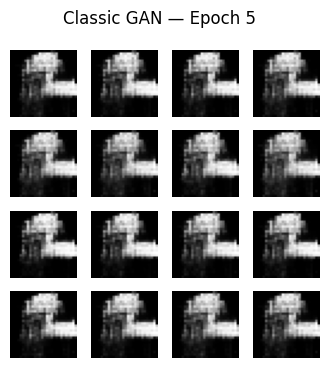

Classic GAN | Epoch 10 | G: 0.8967 | D: 1.0687


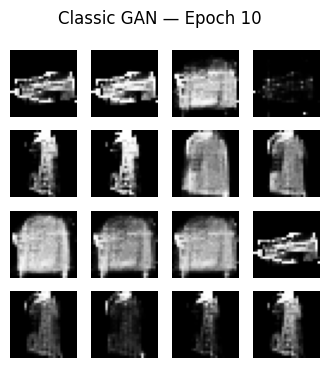

Classic GAN | Epoch 15 | G: 0.8843 | D: 1.3672


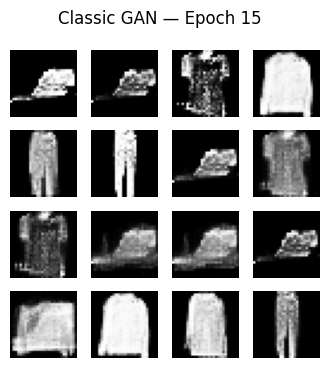

Classic GAN | Epoch 20 | G: 0.9721 | D: 1.0284


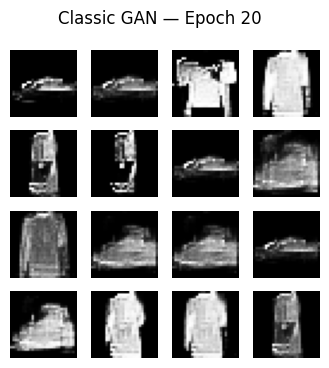

Classic GAN | Epoch 25 | G: 1.0274 | D: 1.0883


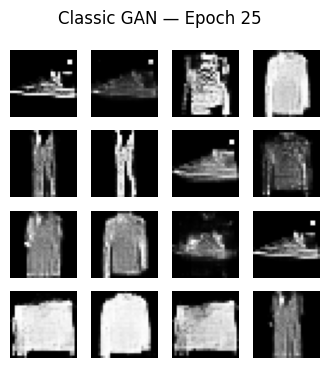

Training Improved DCGAN Generator
Improved DCGAN | Epoch 5 | G: 0.8947 | D: 1.3549


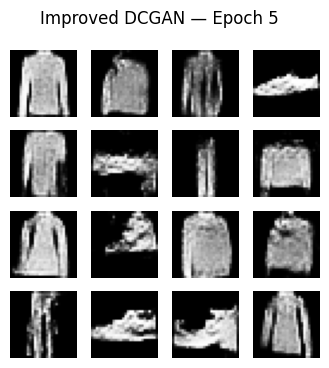

Improved DCGAN | Epoch 10 | G: 0.8832 | D: 1.2772


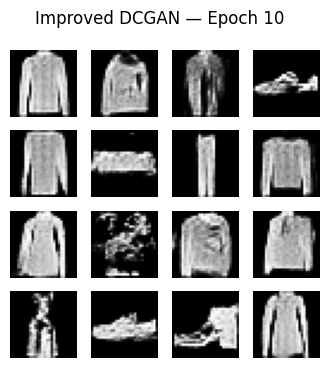

Improved DCGAN | Epoch 15 | G: 0.8208 | D: 1.2883


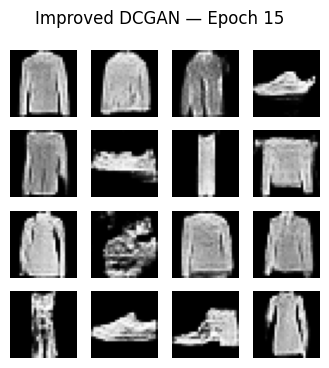

Improved DCGAN | Epoch 20 | G: 0.9226 | D: 1.2364


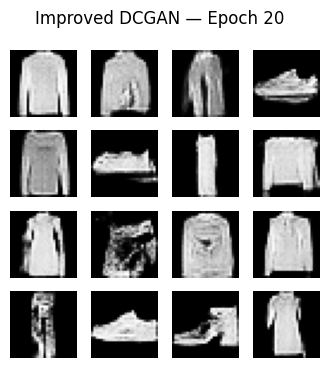

Improved DCGAN | Epoch 25 | G: 0.7994 | D: 1.2506


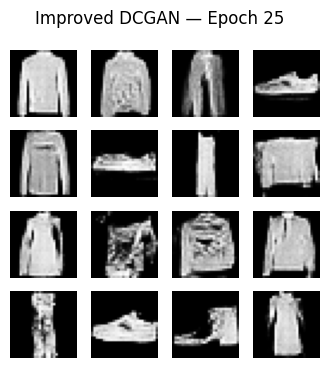

In [ ]:

# Сравнение Classic GAN и Improved DCGAN
# Оптимизировано по времени и памяти

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import mixed_precision
import numpy as np
import matplotlib.pyplot as plt

# 0. Mixed Precision

mixed_precision.set_global_policy('mixed_float16')

# 1. Загрузка и предобработка данных

(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

BUFFER_SIZE = x_train.shape[0]
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# 2. Глобальные параметры

Z_DIM = 100
EPOCHS = 25
LR = 2e-4
BETA_1 = 0.5

# 3. Classic GAN Generator (baseline)

def build_generator_classic():
    model = models.Sequential([
        layers.Dense(256, input_shape=(Z_DIM,)),
        layers.LeakyReLU(0.2),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dense(1024),
        layers.LeakyReLU(0.2),
        layers.Dense(28*28*1, activation='tanh', dtype='float32'),
        layers.Reshape((28, 28, 1))
    ])
    return model

# 4. Improved DCGAN Generator (LIGHT)

def build_generator_dcgan():
    model = models.Sequential([
        layers.Dense(7*7*128, use_bias=False, input_shape=(Z_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, 5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(32, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(
            1, 5, strides=2, padding='same',
            activation='tanh', use_bias=False, dtype='float32'
        )
    ])
    return model

# 5. Discriminator (LIGHT)

def build_discriminator():
    model = models.Sequential([
        layers.Conv2D(32, 5, strides=2, padding='same', input_shape=(28,28,1)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, dtype='float32')
    ])
    return model

# 6. Loss и оптимизаторы

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real, fake):
    real_loss = cross_entropy(tf.ones_like(real), real)
    fake_loss = cross_entropy(tf.zeros_like(fake), fake)
    return real_loss + fake_loss


def g_loss(fake):
    return cross_entropy(tf.ones_like(fake), fake)

# 7. Training step (без tf.function — стабильно)

def train_step(images, generator, discriminator, g_opt, d_opt):
    noise = tf.random.normal([images.shape[0], Z_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated, training=True)

        gen_loss = g_loss(fake_output)
        disc_loss = d_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    g_opt.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    d_opt.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

# 8. Визуализация

def generate_and_save_images(model, epoch, test_input, title):
    predictions = model(test_input, training=False)

    plt.figure(figsize=(4,4))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.suptitle(f"{title} — Epoch {epoch}")
    plt.show()

# 9. Training loop

def train_gan(generator_builder, label):
    generator = generator_builder()
    discriminator = build_discriminator()

    g_opt = tf.keras.optimizers.Adam(LR, beta_1=BETA_1)
    d_opt = tf.keras.optimizers.Adam(LR, beta_1=BETA_1)

    seed = tf.random.normal([16, Z_DIM])

    for epoch in range(1, EPOCHS + 1):
        for batch in train_dataset:
            g_l, d_l = train_step(batch, generator, discriminator, g_opt, d_opt)

        if epoch % 5 == 0:
            print(f"{label} | Epoch {epoch} | G: {g_l:.4f} | D: {d_l:.4f}")
            generate_and_save_images(generator, epoch, seed, label)

    return generator

# 10. Запуск эксперимента

print("Training Classic GAN Generator")
gen_classic = train_gan(build_generator_classic, "Classic GAN")

print("Training Improved DCGAN Generator")
gen_dcgan = train_gan(build_generator_dcgan, "Improved DCGAN")


Заключение

В рамках данной работы было проведено сравнительное исследование двух GAN-моделей для генерации изображений одежды на датасете Fashion-MNIST. В качестве объектов сравнения использовались два различных генератора: классический генератор GAN с полносвязной архитектурой и улучшенный генератор DCGAN, основанный на сверточных слоях с использованием Batch Normalization и апсемплинга посредством Conv2DTranspose.

Экспериментальные результаты показали, что классический GAN способен воспроизводить общие формы объектов одежды, однако характеризуется нестабильностью обучения, размытыми контурами и склонностью к частичному mode collapse. Качество генерации ограничено отсутствием явного моделирования пространственной структуры изображений.

В то же время улучшенный DCGAN продемонстрировал более устойчивое обучение, лучшее визуальное качество и большее разнообразие сгенерированных образцов. Использование сверточной архитектуры позволило модели эффективно учитывать пространственные зависимости, что привело к формированию чётких силуэтов одежды и уменьшению артефактов генерации. Даже при ограниченных вычислительных ресурсах (GPU  T4) улучшенный DCGAN значительно превзошёл классический GAN по всем ключевым критериям.

Таким образом, результаты исследования подтверждают, что архитектура генератора играет решающую роль в задачах генерации изображений. Сверточные генераторы DCGAN являются предпочтительным выбором по сравнению с классическими полносвязными GAN при работе с изображениями, включая задачи генерации объектов одежды.